In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import statsmodels
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf

In [61]:
con = duckdb.connect()

In [62]:
SALES_PATH = "../data/processed/*.parquet"

Business Question

How do we predict the daily demand for each item store combination for next 28 days accurately enough?
- so that we can support the retail inventory and replinshments of the required items in the stores.
- we can avoid stockouts of the items and boost the sales

## Stage 1: Understanding Target Variable 
- Grain of the data
- Sales distribution
- How intermittent the sales is (zero sales vs positive sales)
- Does the intermittent sale prevalent across all the stores for all the products? or only happening for certain combination of items and stores?

In [63]:
# grain of the data - itemxstorexdate

query = f"""

        select s.store_id,s.item_id,s.date,count(*) as grain_count
        from read_parquet('{SALES_PATH}') as s
        group by s.store_id,s.item_id,s.date
        having count(*)>1
        order by s.store_id,s.item_id,s.date
    """

result = con.execute(query).df()
result

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,store_id,item_id,date,grain_count


In [64]:
# grain of the data - itemxstorexdate

query = f"""

        select count(*) as total_observations,min(sales),max(sales),avg(sales),median(sales),stddev(sales)
        from read_parquet('{SALES_PATH}')
    """

result = con.execute(query).df()
result

,total_observations,min(sales),max(sales),avg(sales),median(sales),stddev(sales)
0,58327370,0,763,1.126322,0.0,3.873108


In [65]:
# sales distribution

query = f"""

        select sales, 
        count(*) as sales_dist,
        round(count(*)*100/sum(count(*)) over(),2) as pct
        from read_parquet('{SALES_PATH}')
        where sales <= 1000
        group by sales
        order by sales
    """

result = con.execute(query).df()
result

,sales,sales_dist,pct
0,0,39777094,68.20
1,1,7753194,13.29
2,2,3894493,6.68
3,3,2098127,3.60
4,4,1279524,2.19
...,...,...,...
414,634,1,0.00
415,648,1,0.00
416,693,1,0.00
417,709,2,0.00


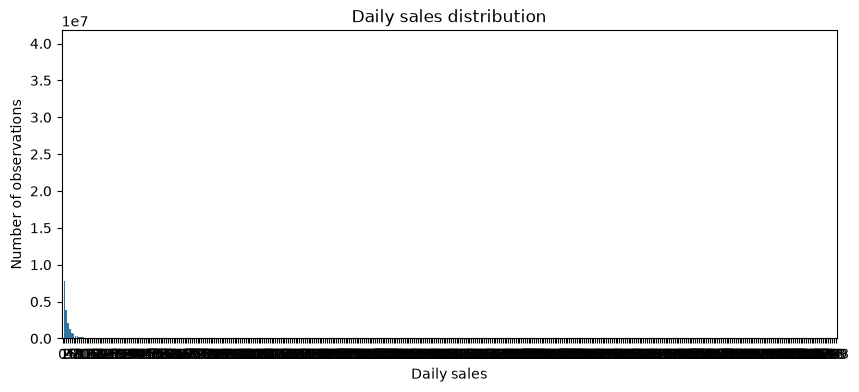

In [66]:
plt.figure(figsize=(10,4))
sns.barplot(data=result, x="sales", y="sales_dist")

plt.title("Daily sales distribution")
plt.xlabel("Daily sales")
plt.ylabel("Number of observations")
plt.show()

In [67]:
# grain of the data - itemxstorexdate

query = f"""

        select 
            case
                when sales=0 then '0'
                when sales between 1 and 5 then '1-5'
                when sales between 6 and 10 then '6-10'
                when sales between 11 and 20 then '11-20'
                when sales between 21 and 50 then '21-50'
                when sales between 51 and 100 then '51-100'                    
                else '100+'
            end as "sales_bucket",
            count(*) as sales_dist
        from read_parquet('{SALES_PATH}')
        group by sales_bucket
                order by 
            case sales_bucket
                when '0' then 1
                when '1-5' then 2
                when '6-10' then 3
                when '11-20' then 4
                when '21-50' then 5
                when '51-100' then 6
                else 7
            end;

    """

result = con.execute(query).df()
result

,sales_bucket,sales_dist
0,0,39777094
1,1-5,15837991
2,6-10,1660736
3,11-20,717960
4,21-50,284985
5,51-100,41548
6,100+,7056


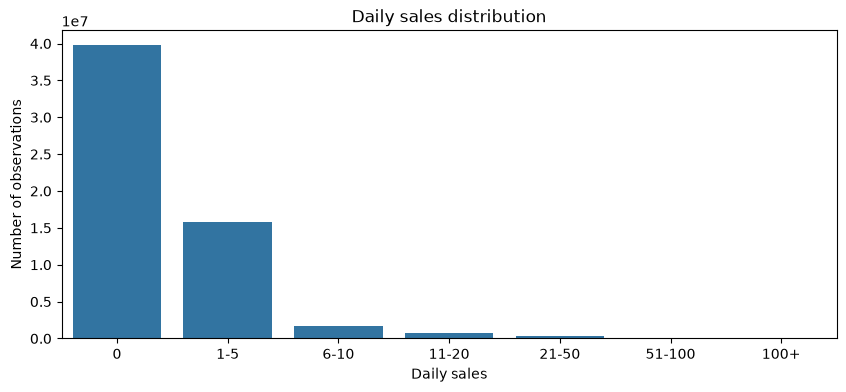

In [68]:
plt.figure(figsize=(10,4))
sns.barplot(data=result, x="sales_bucket", y="sales_dist")

plt.title("Daily sales distribution")
plt.xlabel("Daily sales")
plt.ylabel("Number of observations")
plt.show()

In [69]:
# sales distribution, checking upper tail where the highest unit are sold but their frequency are very less or negligible

query = f"""

        select state_id,store_id,item_id,cat_id,date,weekday,sell_price,sales,event_type_1,event_name_1,snap
        from read_parquet('{SALES_PATH}')
        order by sales desc
        limit 30
    """

result = con.execute(query).df()
result

,state_id,store_id,item_id,cat_id,date,weekday,sell_price,sales,event_type_1,event_name_1,snap
0,CA,CA_3,FOODS_3_090,FOODS,2013-09-14,Saturday,1.00,763,No Event,No Event,0.0
1,CA,CA_3,FOODS_3_090,FOODS,2013-08-23,Friday,1.00,709,No Event,No Event,0.0
2,CA,CA_3,FOODS_3_090,FOODS,2013-09-13,Friday,1.00,709,No Event,No Event,0.0
3,CA,CA_3,FOODS_3_090,FOODS,2011-12-31,Saturday,1.28,693,No Event,No Event,0.0
4,CA,CA_1,FOODS_3_785,FOODS,2012-06-22,Friday,3.34,648,No Event,No Event,0.0
5,TX,TX_1,FOODS_2_285,FOODS,2011-05-06,Friday,2.36,634,No Event,No Event,1.0
6,CA,CA_3,FOODS_3_090,FOODS,2011-12-23,Friday,1.28,633,No Event,No Event,0.0
7,TX,TX_2,HOUSEHOLD_1_474,HOUSEHOLD,2013-07-24,Wednesday,0.97,626,No Event,No Event,0.0
8,CA,CA_3,FOODS_3_090,FOODS,2013-09-11,Wednesday,1.00,620,No Event,No Event,0.0
9,CA,CA_3,FOODS_3_090,FOODS,2011-12-24,Saturday,1.28,619,No Event,No Event,0.0


In [70]:
# sales distribution, checking upper tail where the highest unit are sold but their frequency are very less or negligible

query = f"""
        select store_id,cat_id,weekday,event,snap,price, count(*) as sales_count
        from
        (select store_id,cat_id,weekday,
            case when sell_price between 0.0 and 5.0 then 'low_price'
            else 'high_price'
            end as 'price',
            case when event_type_1='No Event' then 'No Event'
            else 'Event'
            end as 'event',
            snap
        from read_parquet('{SALES_PATH}')
        where sales>400 and sales <800
        )
        group by store_id,cat_id,weekday,event,snap,price
        order by count(*) desc
        
    """

result = con.execute(query).df()
result

,store_id,cat_id,weekday,event,snap,price,sales_count
0,CA_3,FOODS,Saturday,No Event,0.0,low_price,10
1,CA_3,FOODS,Friday,No Event,0.0,low_price,5
2,CA_3,FOODS,Saturday,No Event,1.0,low_price,4
3,CA_3,FOODS,Monday,No Event,0.0,low_price,3
4,CA_3,FOODS,Sunday,No Event,0.0,low_price,3
5,CA_3,FOODS,Wednesday,No Event,0.0,low_price,2
6,CA_3,FOODS,Thursday,No Event,0.0,low_price,2
7,TX_2,HOUSEHOLD,Wednesday,No Event,0.0,low_price,2
8,CA_3,FOODS,Monday,Event,1.0,low_price,1
9,CA_3,FOODS,Sunday,No Event,1.0,low_price,1


In [71]:
# How 68.2% of zero sales distributed? zero sales before and after product launch

query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select 
        count(*) as total_observations,
        count(*) filter(where sales=0) as zero_sales,
        count(*) filter(where sales>0) as positive_sales,
        count(*) filter(where sales=0 and s.date<l.launch_date) as zero_sales_before_launch,
        count(*) filter(where sales=0 and s.date>=l.launch_date) as zero_sales_after_launch,
        round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct,
        round(count(*) filter(where sales>0)/count(*)*100,2) as positive_sales_pct,
        round(count(*) filter(where sales=0 and s.date<l.launch_date)/count(*) filter(sales=0)*100.0,2) as pct_zero_sales_before_launch,
        round(count(*) filter(where sales=0 and s.date>=l.launch_date)/count(*) filter(sales=0)*100.0,2) as pct_zero_sales_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        
    """

result = con.execute(query).df()
result

,total_observations,zero_sales,positive_sales,zero_sales_before_launch,zero_sales_after_launch,zero_sales_pct,positive_sales_pct,pct_zero_sales_before_launch,pct_zero_sales_after_launch
0,58327370,39777094,18550276,12299413,27477681,68.2,31.8,30.92,69.08


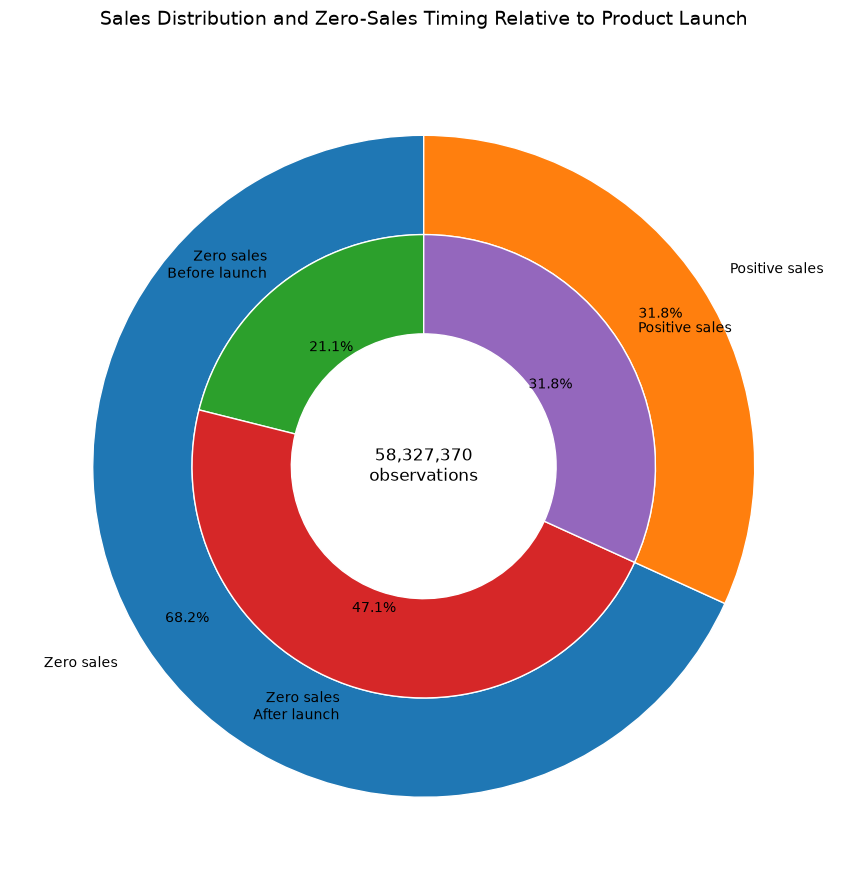

In [72]:
import matplotlib.pyplot as plt

# Values from query
zero_sales = result.loc[0, "zero_sales"]
positive_sales = result.loc[0, "positive_sales"]

zero_before = result.loc[0, "zero_sales_before_launch"]
zero_after = result.loc[0, "zero_sales_after_launch"]

# Total observations
total = result.loc[0, "total_observations"]


outer_values = [zero_sales, positive_sales]
outer_labels = ["Zero sales", "Positive sales"]


inner_values = [zero_before, zero_after, positive_sales]
inner_labels = [
    "Zero sales\nBefore launch",
    "Zero sales\nAfter launch",
    "Positive sales"
]

fig, ax = plt.subplots(figsize=(9, 9))

# Outer ring
ax.pie(
    outer_values,
    radius=1,
    labels=outer_labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.30, edgecolor="white"),
    pctdistance=0.85
)

# Inner ring
ax.pie(
    inner_values,
    radius=0.70,
    labels=inner_labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.30, edgecolor="white"),
    pctdistance=0.65
)

# Centre
ax.text(
    0, 0,
    f"{total:,}\nobservations",
    ha="center",
    va="center",
    fontsize=12
)

ax.set_title(
    "Sales Distribution and Zero-Sales Timing Relative to Product Launch",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

In [73]:
# Lets explore the zero sale after the product launch whether is it consistent across all the items and stores or happening for only some of the item-store combination.


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.store_id,s.item_id,
            round(count(*) filter(where sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as pct_zero_sales_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.store_id,s.item_id
        
    """

result = con.execute(query).df()
result["pct_zero_sales_after_launch"].describe()


count    30490.000000
mean        60.210202
std         23.363432
min          0.160000
25%         43.340000
50%         63.525000
75%         79.727500
max         99.310000
Name: pct_zero_sales_after_launch, dtype: float64

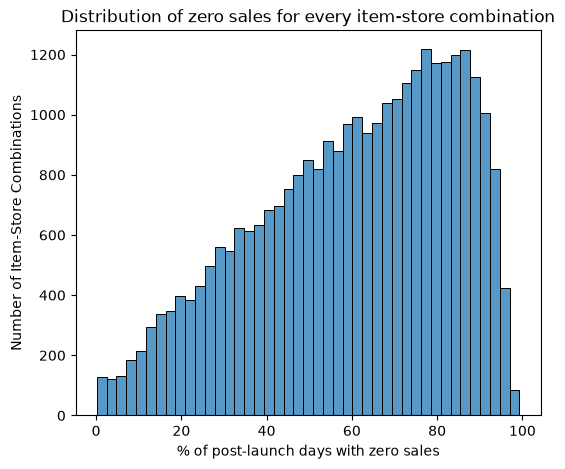

In [74]:
plt.figure(figsize=(6,5))
sns.histplot(data=result, x="pct_zero_sales_after_launch")
plt.title("Distribution of zero sales for every item-store combination")
plt.xlabel("% of post-launch days with zero sales")
plt.ylabel("Number of Item-Store Combinations")

plt.show()

## Stage 2: Understanding how the target i.e sales behaves through time (how demand changes over the time)
- Overa all trend
- Seasonality (weekly, monthly etc)
- Dependency on previous day's sales
  

In [75]:
# How does sales behaves over the years? Does the sale increased or decreased? is there any trend?


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.year,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.year
        order by s.year
        
    """

result = con.execute(query).df()
result


,year,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days
0,2011,55.37,44.63,1.733855,3.885017
1,2012,57.93,42.07,1.669329,3.967669
2,2013,60.11,39.89,1.481031,3.713217
3,2014,62.17,37.83,1.272176,3.363249
4,2015,60.78,39.22,1.251216,3.190479
5,2016,57.92,42.08,1.355068,3.219961


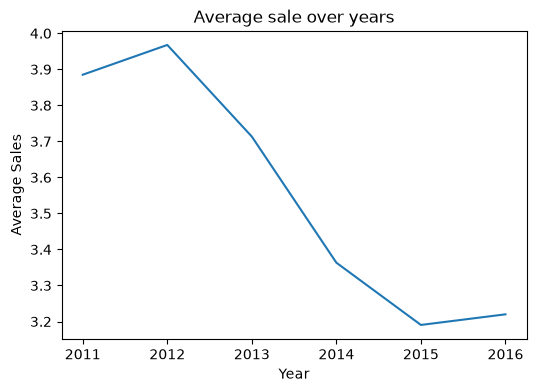

In [76]:
plt.figure(figsize=(6,4))
sns.lineplot(data=result,x="year",y="avg_sales_positive_days")
plt.title("Average sale over years")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.show()

In [77]:
query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.year,s.month,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>l.launch_date) as total_sales,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.year,s.month
        order by s.year,s.month
        
    """

result = con.execute(query).df()
result[result["year"]==2014]


,year,month,zero_sales_pct,postive_sales_pct,total_sales,avg_sales_positive_days
36,2014,1,62.79,37.21,1.303792,3.502754
37,2014,2,61.02,38.98,1.356639,3.478596
38,2014,3,61.27,38.73,1.332394,3.438050
39,2014,4,61.62,38.38,1.333743,3.473802
40,2014,5,62.35,37.65,1.261311,3.348934
41,2014,6,62.07,37.93,1.309082,3.450430
42,2014,7,62.44,37.56,1.301807,3.464786
43,2014,8,61.65,38.35,1.327329,3.460718
44,2014,9,61.83,38.17,1.251395,3.277812
45,2014,10,61.56,38.44,1.219035,3.170812


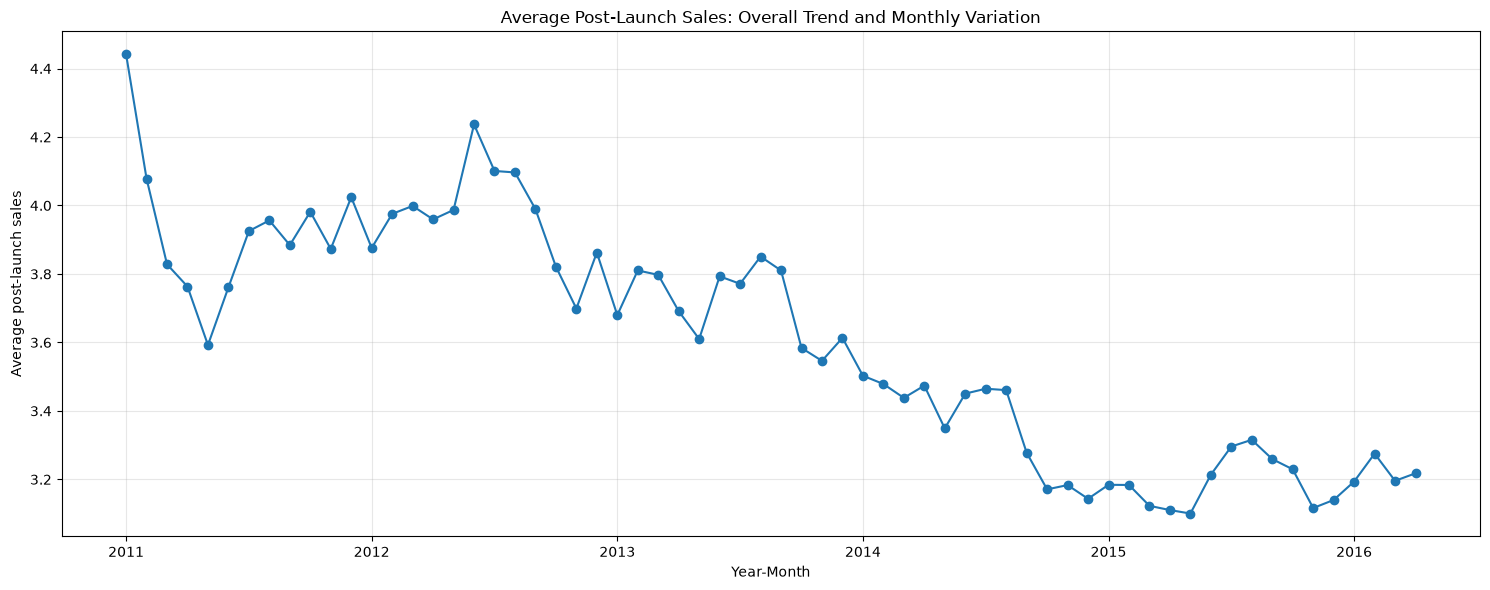

In [78]:
import matplotlib.pyplot as plt

result["year_month"] = (
    result["year"].astype(str) + "-" +
    result["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(15, 6))

plt.plot(
    result["year_month"],
    result["avg_sales_positive_days"],
    marker="o"
)

plt.xlabel("Year-Month")
plt.ylabel("Average post-launch sales")
plt.title("Average Post-Launch Sales: Overall Trend and Monthly Variation")

# Show only January as the year labels
jan_positions = result["month"] == 1

plt.xticks(
    result.index[jan_positions],
    result.loc[jan_positions, "year"],
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

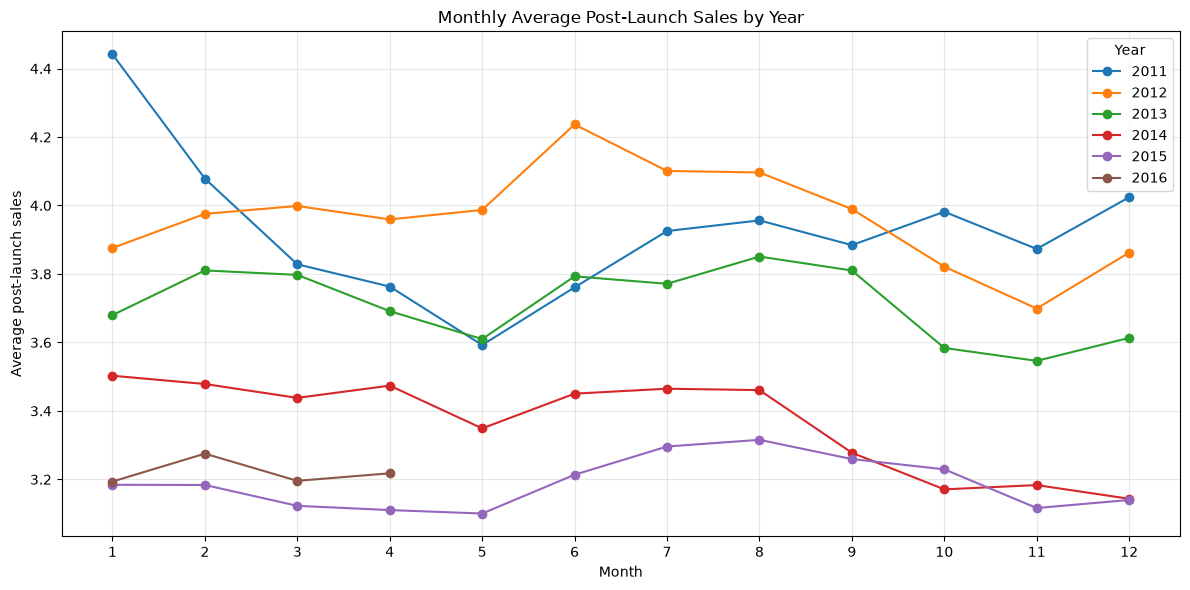

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for year, group in result.groupby("year"):
    plt.plot(
        group["month"],
        group["avg_sales_positive_days"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Average post-launch sales")
plt.title("Monthly Average Post-Launch Sales by Year")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.month,s.weekday,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>l.launch_date) as total_sales,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.month,s.weekday
        order by s.month,s.weekday
        
    """

result = con.execute(query).df()
result


,month,weekday,zero_sales_pct,postive_sales_pct,total_sales,avg_sales_positive_days
0,1,Friday,60.55,39.45,1.336962,3.389298
1,1,Monday,61.03,38.97,1.320346,3.388296
2,1,Saturday,55.12,44.88,1.719157,3.877429
3,1,Sunday,56.47,43.53,1.658417,3.809434
4,1,Thursday,63.41,36.59,1.166418,3.187453
...,...,...,...,...,...,...
79,12,Saturday,57.51,42.49,1.621332,3.811140
80,12,Sunday,59.57,40.43,1.503699,3.719249
81,12,Thursday,64.01,35.99,1.217403,3.382751
82,12,Tuesday,64.12,35.88,1.184606,3.301216


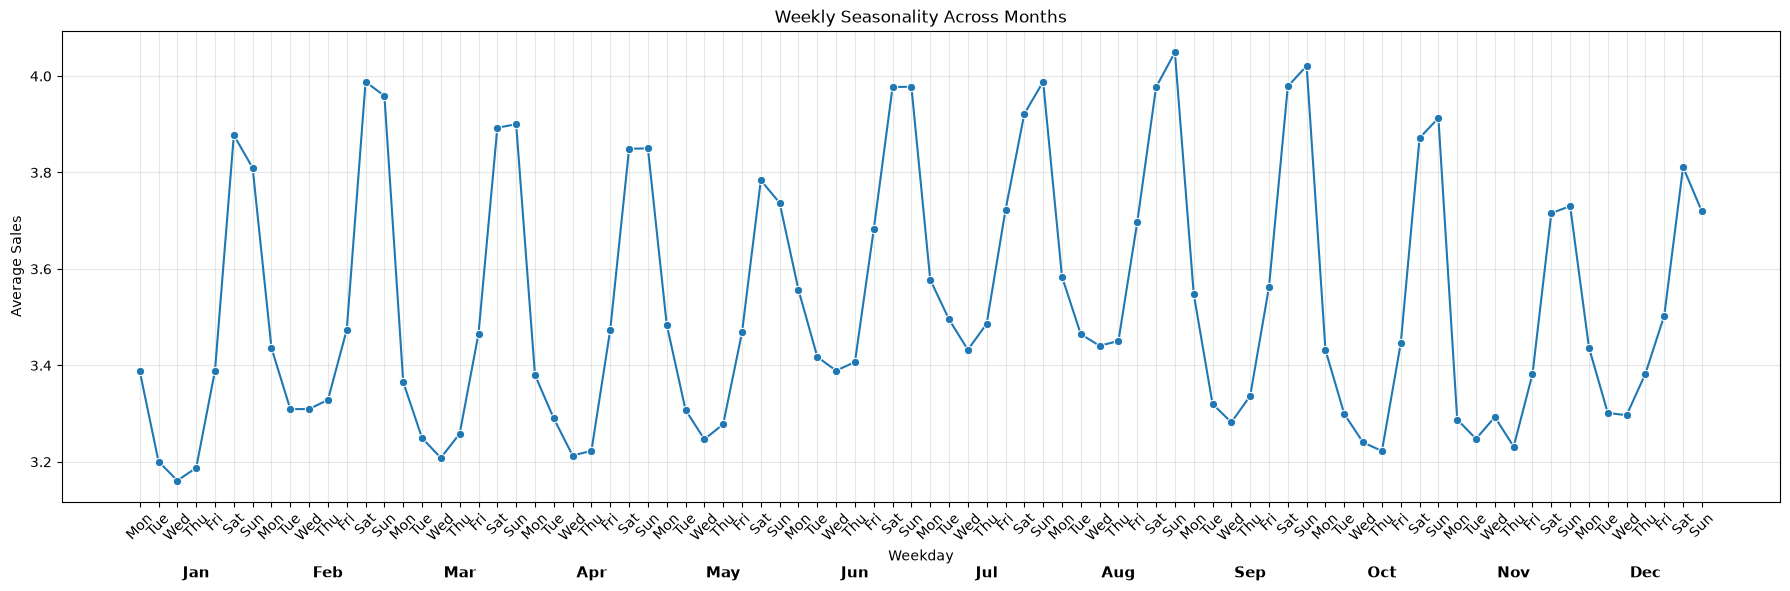

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

# Create ordered month-weekday combination
result["month_weekday"] = (
    result["month"].astype(int).astype(str)
    + "_"
    + result["weekday"].astype(str)
)

month_weekday_order = [
    f"{month}_{weekday}"
    for month in range(1, 13)
    for weekday in weekday_order
]

result["month_weekday"] = pd.Categorical(
    result["month_weekday"],
    categories=month_weekday_order,
    ordered=True
)

plt.figure(figsize=(18, 6))

sns.lineplot(
    data=result,
    x="month_weekday",
    y="avg_sales_positive_days",
    marker="o"
)

# Weekday labels
plt.xticks(
    range(84),
    [day[:3] for month in range(1, 13) for day in weekday_order],
    rotation=45
)

# Add month labels underneath
for i, month in enumerate(range(1, 13)):
    center = i * 7 + 3

    plt.text(
        center,
        -0.16,
        month_names[month],
        transform=plt.gca().get_xaxis_transform(),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Weekly Seasonality Across Months")
plt.xlabel("Weekday")
plt.ylabel("Average Sales")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
# How does sales behaves over the years for products and stores?


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.year,s.cat_id,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.year,s.cat_id
        order by s.cat_id,s.year
        
    """

result = con.execute(query).df()
result


,year,cat_id,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days
0,2011,FOODS,45.57,54.43,2.643032,4.856124
1,2012,FOODS,47.65,52.35,2.618367,5.002101
2,2013,FOODS,51.57,48.43,2.184026,4.509269
3,2014,FOODS,54.04,45.96,1.881647,4.094384
4,2015,FOODS,53.76,46.24,1.743348,3.770506
5,2016,FOODS,49.26,50.74,1.918434,3.780716
6,2011,HOBBIES,65.96,34.04,1.023359,3.006226
7,2012,HOBBIES,71.19,28.81,0.702508,2.438245
8,2013,HOBBIES,71.80,28.20,0.714089,2.532597
9,2014,HOBBIES,74.36,25.64,0.603979,2.355261


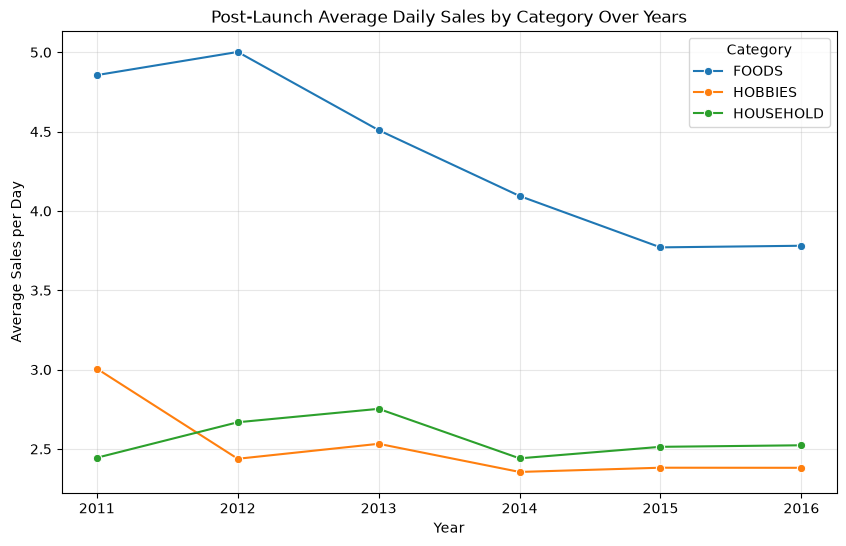

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=result,
    x="year",
    y="avg_sales_positive_days",
    hue="cat_id",
    marker="o"
)

plt.title("Post-Launch Average Daily Sales by Category Over Years")
plt.xlabel("Year")
plt.ylabel("Average Sales per Day")
plt.xticks(sorted(result["year"].unique()))
plt.legend(title="Category")
plt.grid(alpha=0.3)

plt.show()

### Lets explore the trend, seasonality for individual time series to see varied patterns in the data.
- We will explore 3 different series for item-store combination where one representing high sales with low intermittency.
- Second series with middle demand
- Final series with high level of intermittent sales and very low demand.

Rows: 1913 | Expected calendar days in range: 1913 | Missing: 0


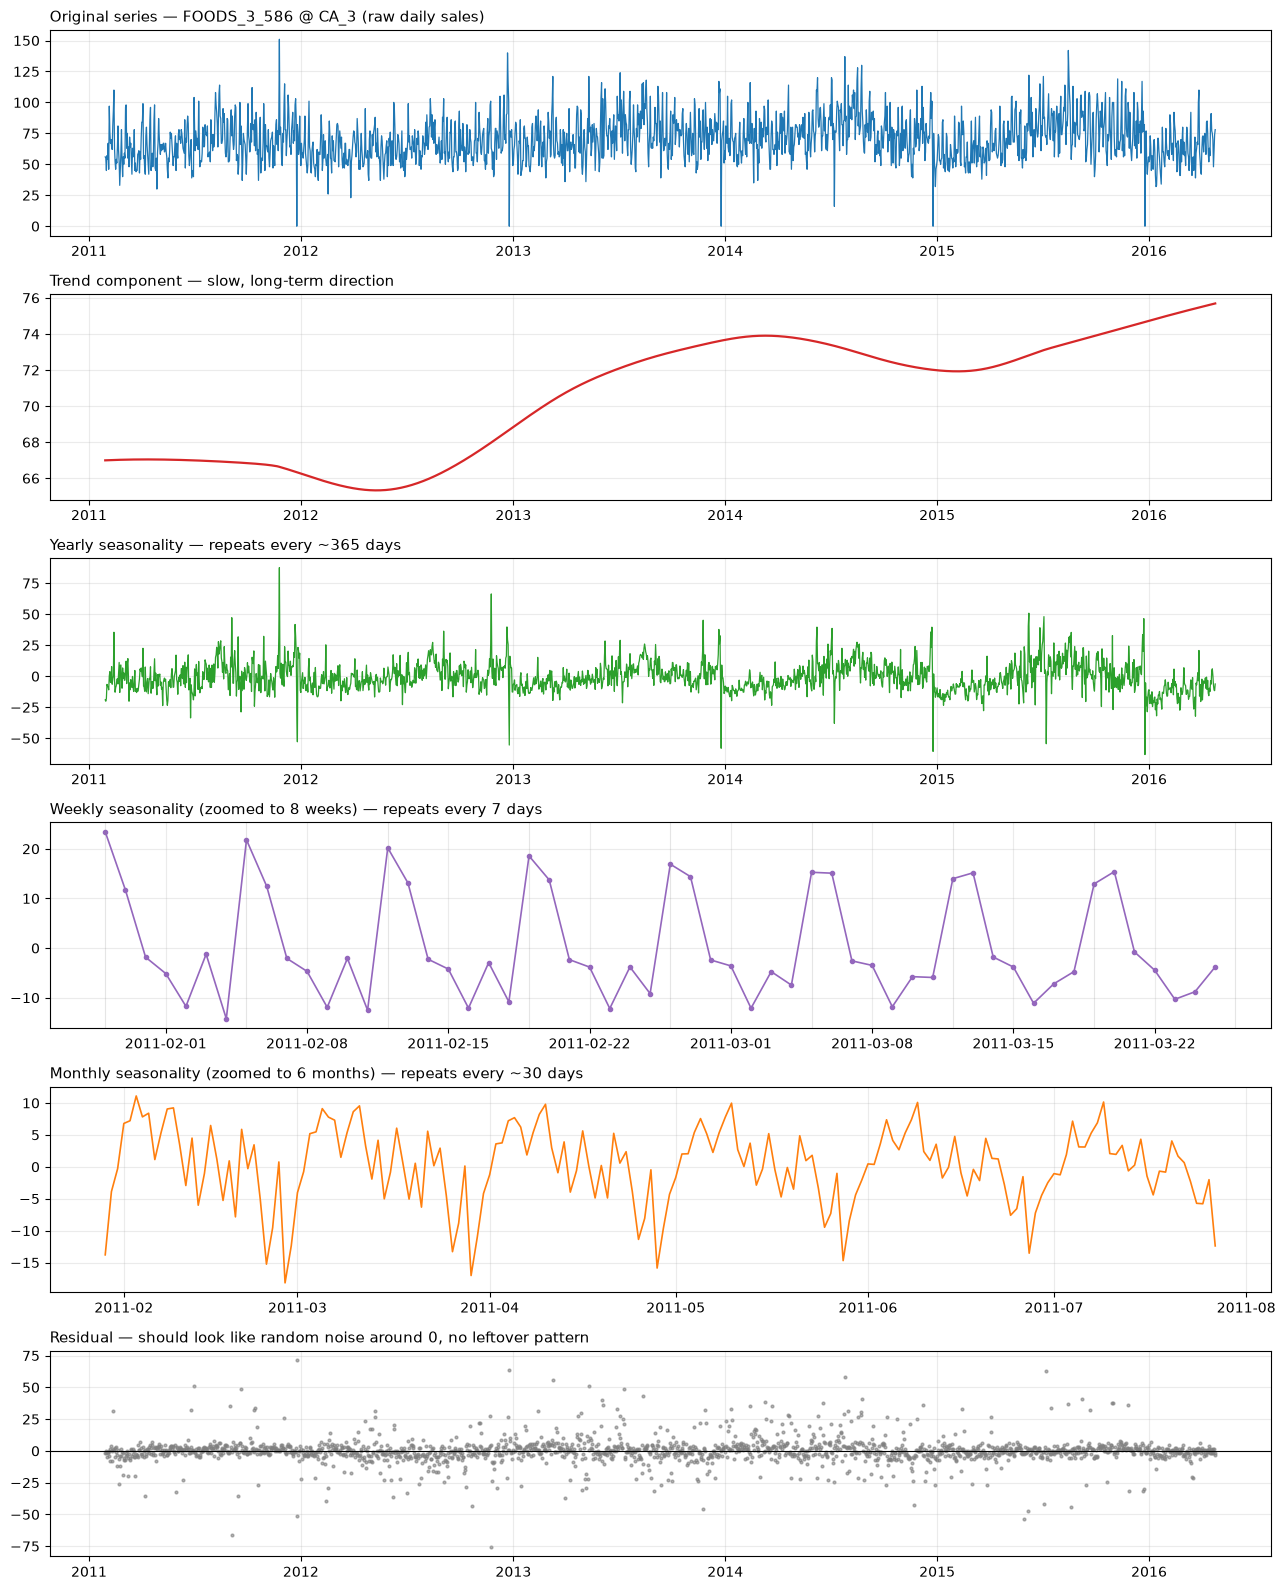

In [84]:
#1. Item with high demand and sales

query = f"""

            with launch as (
                select item_id,store_id,min(date) as launch_date
                from read_parquet('{SALES_PATH}')
                where sell_price is not null 
                group by item_id,store_id
            )
                select
                    date,
                    sales,launch_date
                from read_parquet('{SALES_PATH}') as s
                join launch as l
                    on s.store_id=l.store_id
                    and s.item_id=l.item_id
                where s.store_id='CA_3'
                and s.item_id='FOODS_3_586'
                and s.date>=l.launch_date
                order by date
                """

df = con.execute(query).df()


df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
series = df["sales"]


expected_days = (series.index.max() - series.index.min()).days + 1
print(
    f"Rows: {len(series)} | Expected calendar days in range: {expected_days} | "
    f"Missing: {expected_days - len(series)}"
)

mstl = MSTL(series, periods=(7, 30, 365), stl_kwargs={"robust": True}).fit()

trend_est = mstl.trend
weekly_est = mstl.seasonal["seasonal_7"]
monthly_est = mstl.seasonal["seasonal_30"]
yearly_est = mstl.seasonal["seasonal_365"]
resid_final = mstl.resid

fig, axes = plt.subplots(6, 1, figsize=(13, 16), sharex=False)

axes[0].plot(series.index, series.values, color="#1f77b4", linewidth=0.9)
axes[0].set_title(
    "Original series — FOODS_3_586 @ CA_3 (raw daily sales)", fontsize=11, loc="left"
)

axes[1].plot(trend_est.index, trend_est.values, color="#d62728", linewidth=1.6)
axes[1].set_title(
    "Trend component — slow, long-term direction", fontsize=11, loc="left"
)

axes[2].plot(yearly_est.index, yearly_est.values, color="#2ca02c", linewidth=0.9)
axes[2].set_title(
    "Yearly seasonality — repeats every ~365 days", fontsize=11, loc="left"
)

zoom_weeks = 8
zoom = slice(0, zoom_weeks * 7)
axes[3].plot(
    weekly_est.index[zoom],
    weekly_est.values[zoom],
    color="#9467bd",
    marker="o",
    markersize=3,
    linewidth=1.2,
)
axes[3].set_title(
    f"Weekly seasonality (zoomed to {zoom_weeks} weeks) — repeats every 7 days",
    fontsize=11,
    loc="left",
)
for i in range(0, zoom_weeks * 7 + 1, 7):
    axes[3].axvline(
        weekly_est.index[0] + pd.Timedelta(days=i),
        color="gray",
        alpha=0.2,
        linewidth=0.8,
    )

zoom_months_days = 180
zoom_m = slice(0, zoom_months_days)
axes[4].plot(
    monthly_est.index[zoom_m],
    monthly_est.values[zoom_m],
    color="#ff7f0e",
    linewidth=1.2,
)
axes[4].set_title(
    "Monthly seasonality (zoomed to 6 months) — repeats every ~30 days",
    fontsize=11,
    loc="left",
)

axes[5].scatter(resid_final.index, resid_final.values, color="#7f7f7f", s=4, alpha=0.6)
axes[5].axhline(0, color="black", linewidth=0.8)
axes[5].set_title(
    "Residual — should look like random noise around 0, no leftover pattern",
    fontsize=11,
    loc="left",
)

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("mstl_decomposition.png", dpi=140)
plt.show()

Rows: 1913 | Expected calendar days in range: 1913 | Missing: 0


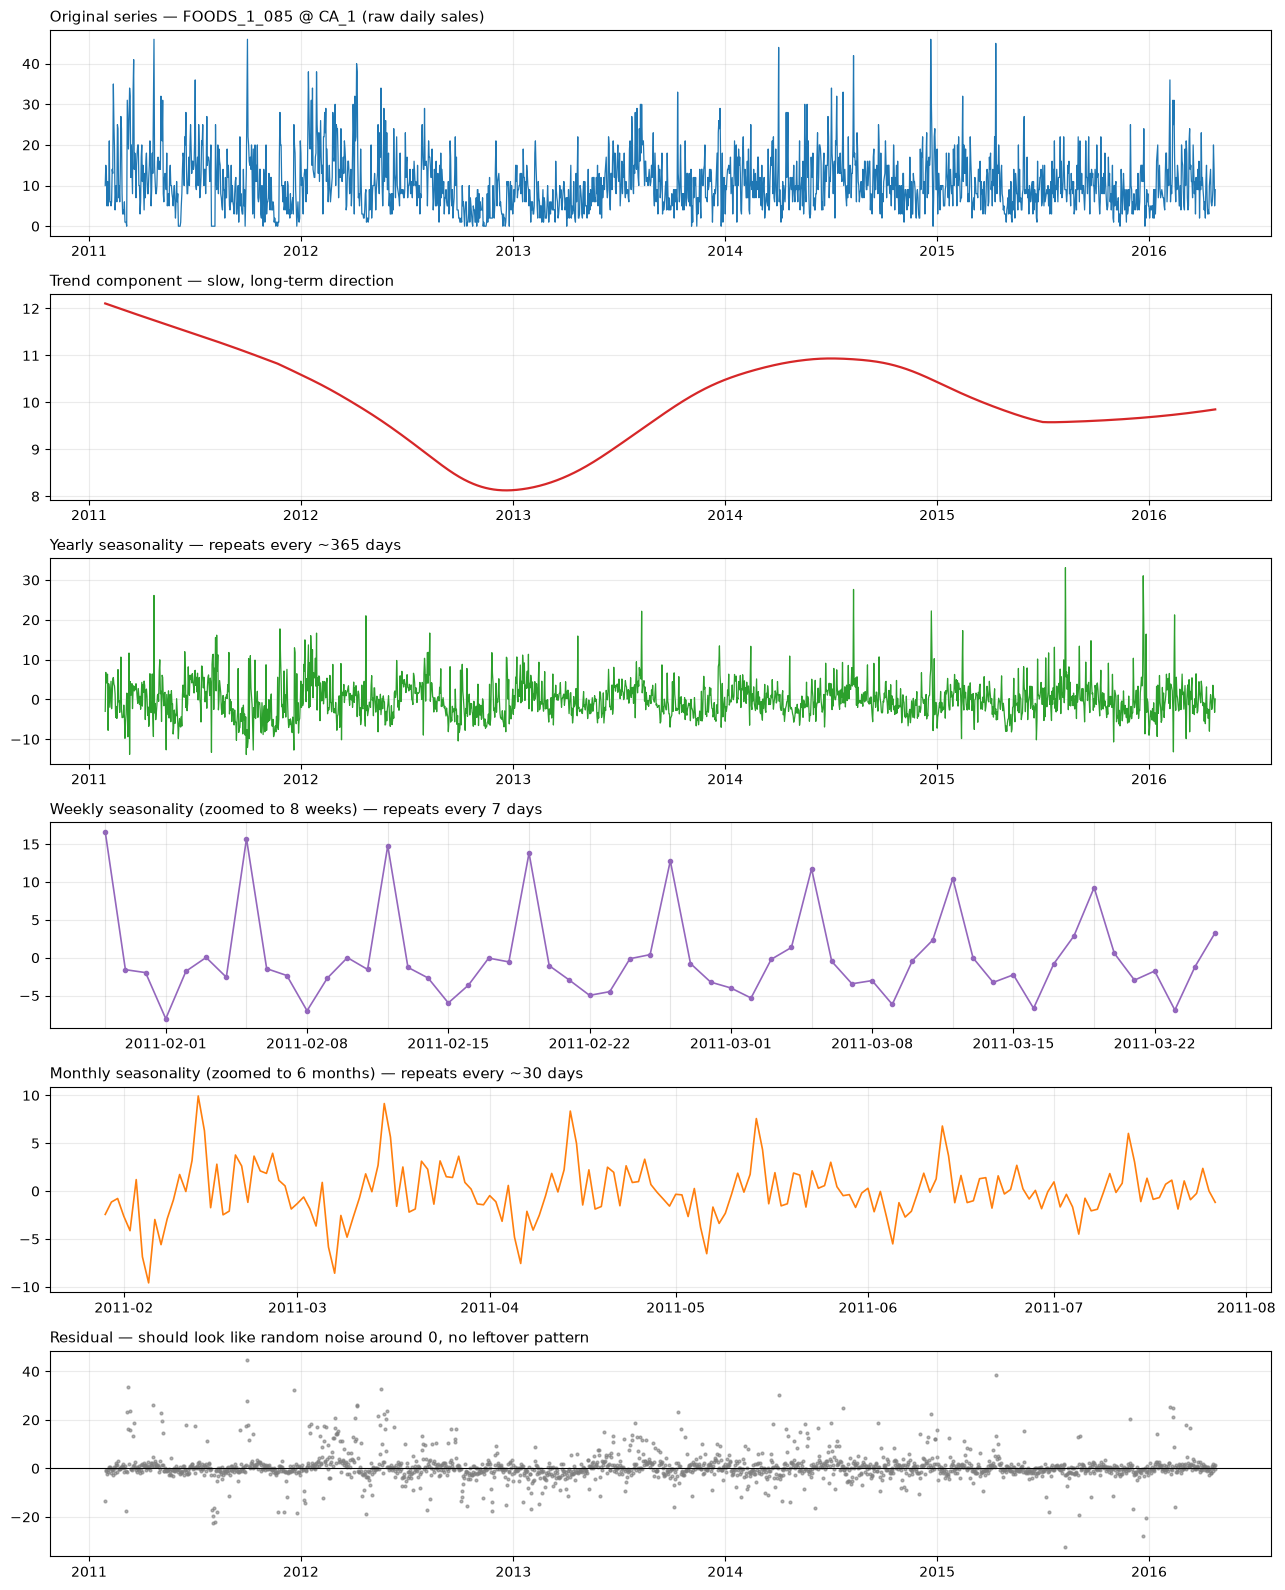

In [85]:
# Series with midrange intermittent sales and low total sales
query = f"""

            with launch as (
                select item_id,store_id,min(date) as launch_date
                from read_parquet('{SALES_PATH}')
                where sell_price is not null 
                group by item_id,store_id
            )
                select
                    date,
                    sales,launch_date
                from read_parquet('{SALES_PATH}') as s
                join launch as l
                    on s.store_id=l.store_id
                    and s.item_id=l.item_id
                where s.store_id='CA_1'
                and s.item_id='FOODS_1_085'
                and s.date>=l.launch_date
                order by date
                """

df = con.execute(query).df()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
series = df["sales"]


expected_days = (series.index.max() - series.index.min()).days + 1
print(
    f"Rows: {len(series)} | Expected calendar days in range: {expected_days} | "
    f"Missing: {expected_days - len(series)}"
)


mstl = MSTL(series, periods=(7, 30, 365), stl_kwargs={"robust": True}).fit()

trend_est = mstl.trend
weekly_est = mstl.seasonal["seasonal_7"]
monthly_est = mstl.seasonal["seasonal_30"]
yearly_est = mstl.seasonal["seasonal_365"]
resid_final = mstl.resid


fig, axes = plt.subplots(6, 1, figsize=(13, 16), sharex=False)

axes[0].plot(series.index, series.values, color="#1f77b4", linewidth=0.9)
axes[0].set_title(
    "Original series — FOODS_1_085 @ CA_1 (raw daily sales)", fontsize=11, loc="left"
)

axes[1].plot(trend_est.index, trend_est.values, color="#d62728", linewidth=1.6)
axes[1].set_title(
    "Trend component — slow, long-term direction", fontsize=11, loc="left"
)

axes[2].plot(yearly_est.index, yearly_est.values, color="#2ca02c", linewidth=0.9)
axes[2].set_title(
    "Yearly seasonality — repeats every ~365 days", fontsize=11, loc="left"
)


zoom_weeks = 8
zoom = slice(0, zoom_weeks * 7)
axes[3].plot(
    weekly_est.index[zoom],
    weekly_est.values[zoom],
    color="#9467bd",
    marker="o",
    markersize=3,
    linewidth=1.2,
)
axes[3].set_title(
    f"Weekly seasonality (zoomed to {zoom_weeks} weeks) — repeats every 7 days",
    fontsize=11,
    loc="left",
)
for i in range(0, zoom_weeks * 7 + 1, 7):
    axes[3].axvline(
        weekly_est.index[0] + pd.Timedelta(days=i),
        color="gray",
        alpha=0.2,
        linewidth=0.8,
    )


zoom_months_days = 180
zoom_m = slice(0, zoom_months_days)
axes[4].plot(
    monthly_est.index[zoom_m],
    monthly_est.values[zoom_m],
    color="#ff7f0e",
    linewidth=1.2,
)
axes[4].set_title(
    "Monthly seasonality (zoomed to 6 months) — repeats every ~30 days",
    fontsize=11,
    loc="left",
)

axes[5].scatter(resid_final.index, resid_final.values, color="#7f7f7f", s=4, alpha=0.6)
axes[5].axhline(0, color="black", linewidth=0.8)
axes[5].set_title(
    "Residual — should look like random noise around 0, no leftover pattern",
    fontsize=11,
    loc="left",
)

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("mstl_decomposition.png", dpi=140)
plt.show()

Rows: 1332 | Expected calendar days in range: 1332 | Missing: 0


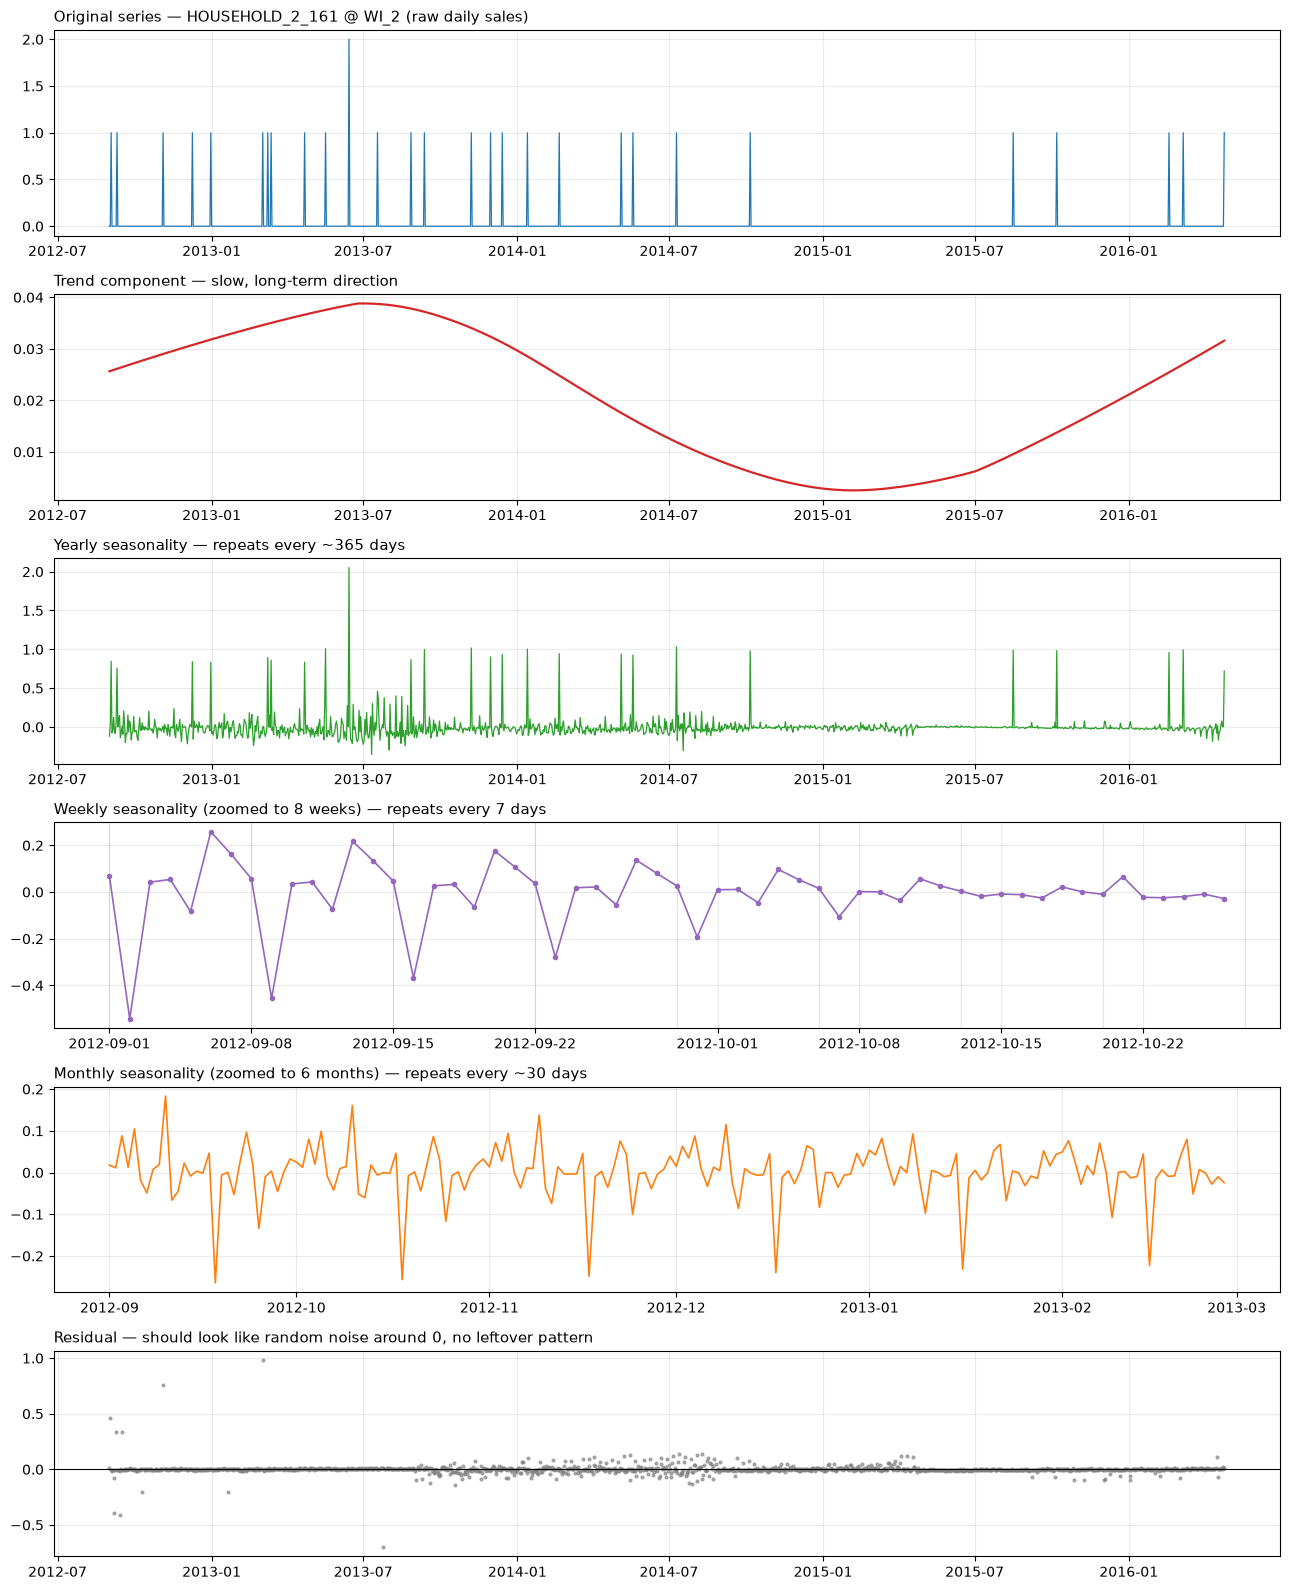

In [86]:
# 3. Series with high intermittent and low total sales

query = f"""

            with launch as (
                select item_id,store_id,min(date) as launch_date
                from read_parquet('{SALES_PATH}')
                where sell_price is not null 
                group by item_id,store_id
            )
                select
                    date,
                    sales,launch_date
                from read_parquet('{SALES_PATH}') as s
                join launch as l
                    on s.store_id=l.store_id
                    and s.item_id=l.item_id
                where s.store_id='WI_2'
                and s.item_id='HOUSEHOLD_2_161'
                and s.date>=l.launch_date
                order by date
                """

df = con.execute(query).df()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
series = df["sales"]

expected_days = (series.index.max() - series.index.min()).days + 1
print(
    f"Rows: {len(series)} | Expected calendar days in range: {expected_days} | "
    f"Missing: {expected_days - len(series)}"
)

mstl = MSTL(series, periods=(7, 30, 365), stl_kwargs={"robust": True}).fit()

trend_est = mstl.trend
weekly_est = mstl.seasonal["seasonal_7"]
monthly_est = mstl.seasonal["seasonal_30"]
yearly_est = mstl.seasonal["seasonal_365"]
resid_final = mstl.resid

fig, axes = plt.subplots(6, 1, figsize=(13, 16), sharex=False)

axes[0].plot(series.index, series.values, color="#1f77b4", linewidth=0.9)
axes[0].set_title(
    "Original series — HOUSEHOLD_2_161 @ WI_2 (raw daily sales)", fontsize=11, loc="left"
)

axes[1].plot(trend_est.index, trend_est.values, color="#d62728", linewidth=1.6)
axes[1].set_title(
    "Trend component — slow, long-term direction", fontsize=11, loc="left"
)

axes[2].plot(yearly_est.index, yearly_est.values, color="#2ca02c", linewidth=0.9)
axes[2].set_title(
    "Yearly seasonality — repeats every ~365 days", fontsize=11, loc="left"
)

zoom_weeks = 8
zoom = slice(0, zoom_weeks * 7)
axes[3].plot(
    weekly_est.index[zoom],
    weekly_est.values[zoom],
    color="#9467bd",
    marker="o",
    markersize=3,
    linewidth=1.2,
)
axes[3].set_title(
    f"Weekly seasonality (zoomed to {zoom_weeks} weeks) — repeats every 7 days",
    fontsize=11,
    loc="left",
)
for i in range(0, zoom_weeks * 7 + 1, 7):
    axes[3].axvline(
        weekly_est.index[0] + pd.Timedelta(days=i),
        color="gray",
        alpha=0.2,
        linewidth=0.8,
    )

zoom_months_days = 180
zoom_m = slice(0, zoom_months_days)
axes[4].plot(
    monthly_est.index[zoom_m],
    monthly_est.values[zoom_m],
    color="#ff7f0e",
    linewidth=1.2,
)
axes[4].set_title(
    "Monthly seasonality (zoomed to 6 months) — repeats every ~30 days",
    fontsize=11,
    loc="left",
)

axes[5].scatter(resid_final.index, resid_final.values, color="#7f7f7f", s=4, alpha=0.6)
axes[5].axhline(0, color="black", linewidth=0.8)
axes[5].set_title(
    "Residual — should look like random noise around 0, no leftover pattern",
    fontsize=11,
    loc="left",
)

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("mstl_decomposition.png", dpi=140)
plt.show()

In [ ]:
series_configs = [
    ("FOODS_1_001", "CA_1"),
    ("HOUSEHOLD_1_001", "TX_1"),
    ("HOBBIES_1_001", "WI_1"),
]

for item_id, store_id in series_configs:

    query = """
        SELECT date, sales
        FROM read_parquet(?)
        WHERE item_id = ?
        AND store_id = ?
        ORDER BY date
    """

    series = con.execute(
        query,
        [SALES_PATH,item_id, store_id]
    ).df()

    # Apply your launch-date filtering here

    plot_acf(
        series["sales"],
        lags=56
    )

    plt.title(f"ACF: {item_id} - {store_id}")
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.show()

IOException: IO Error: No files found that match the pattern "{SALES_PATH}"

LINE 3:         FROM read_parquet('{SALES_PATH}')
                     ^

| Series type | Intermittency | Trend      | Weekly seasonality | Monthly/yearly pattern |
| ----------- | ------------- | ---------- | ------------------ | ---------------------- |
| Series 1    | Low           | Clear      | Strong             | Stronger               |
| Series 2    | Medium        | Some       | Moderate           | Moderate               |
| Series 3    | High          | Weak/noisy | Weak               | Weak                   |


In [ ]:
# How does sales behaves over the years for products and stores?


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.store_id,s.cat_id,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days,
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.store_id,s.cat_id
        order by s.cat_id,s.store_id
        
    """

result = con.execute(query).df()
result


,store_id,cat_id,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days
0,CA_1,FOODS,46.94,53.06,2.423791,4.567781
1,CA_2,FOODS,50.39,49.61,1.925728,3.881432
2,CA_3,FOODS,40.92,59.08,3.388849,5.736390
3,CA_4,FOODS,55.36,44.64,1.294291,2.899080
4,TX_1,FOODS,56.86,43.14,1.691200,3.920353
5,TX_2,FOODS,51.79,48.21,2.242696,4.651843
6,TX_3,FOODS,55.51,44.49,1.907481,4.287308
7,WI_1,FOODS,49.25,50.75,1.716291,3.381821
8,WI_2,FOODS,51.05,48.95,2.266103,4.629610
9,WI_3,FOODS,53.74,46.26,2.138349,4.622373


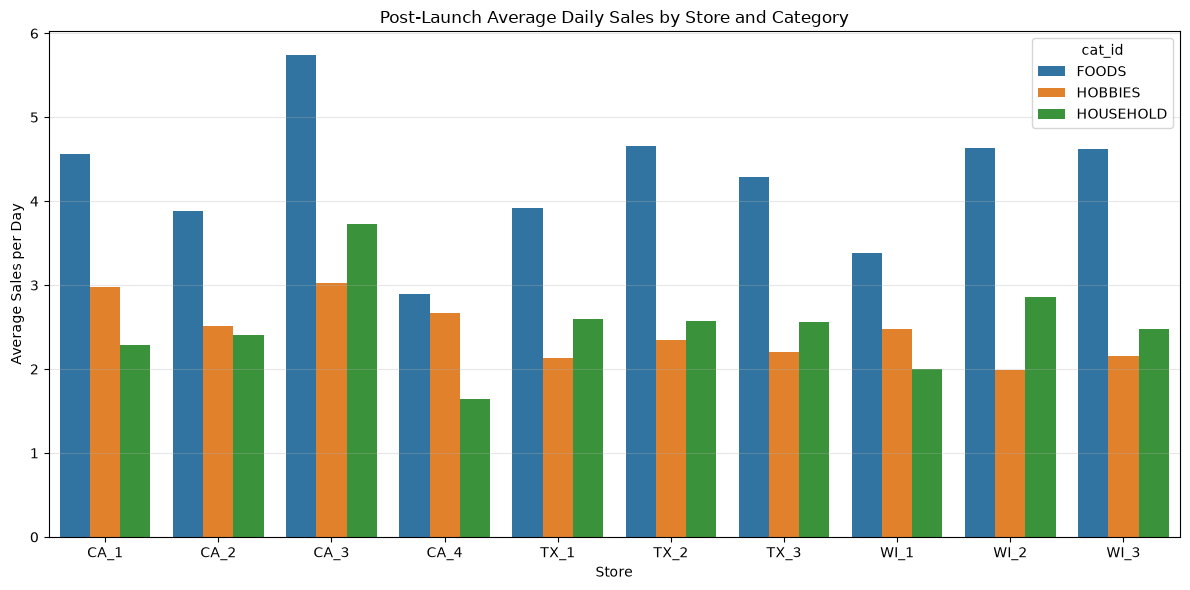

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=result,
    x="store_id",
    y="avg_sales_positive_days",
    hue="cat_id"
)

plt.title("Post-Launch Average Daily Sales by Store and Category")
plt.xlabel("Store")
plt.ylabel("Average Sales per Day")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

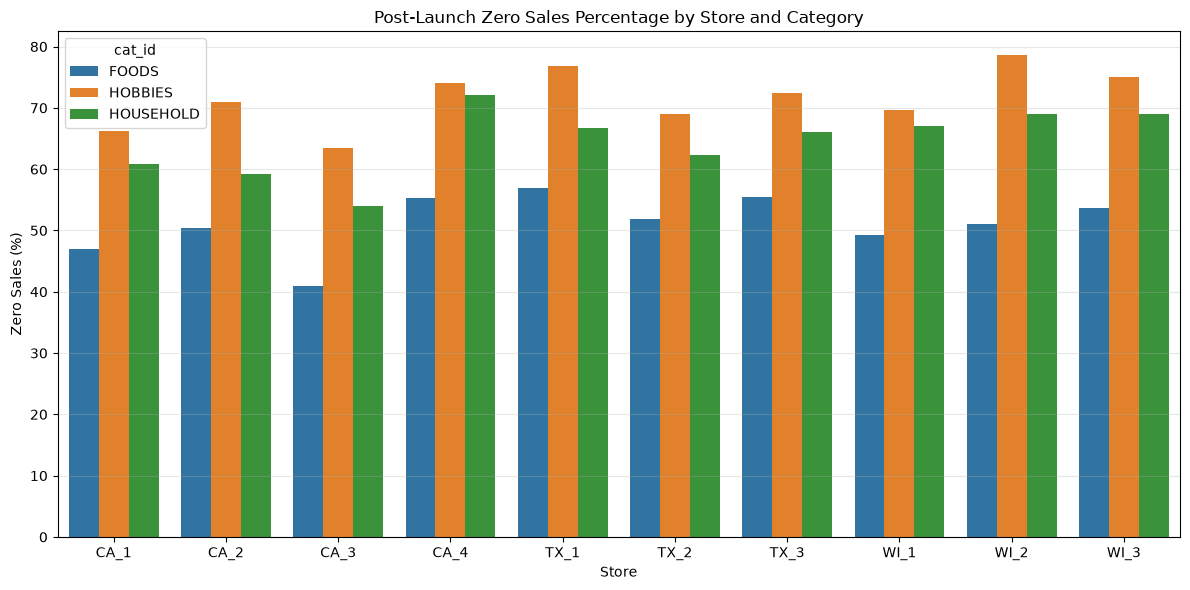

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=result,
    x="store_id",
    y="zero_sales_pct",
    hue="cat_id"
)

plt.title("Post-Launch Zero Sales Percentage by Store and Category")
plt.xlabel("Store")
plt.ylabel("Zero Sales (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Stage 3: Assosciation of business drivers like Snap, Events and Selling Price on Sales
- Impact of SNAP on total sales
- Impact of events on sales
- Assosciation of low or highly weekly prices on sales demand and intermittency.
  

In [ ]:
#

query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.snap,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days,
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.snap
        order by s.snap
        
    """

result = con.execute(query).df()
result


,snap,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days
0,0.0,60.27,39.73,1.368621,3.444741
1,1.0,58.53,41.47,1.547151,3.730810


In [ ]:
#

query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.snap,
            case 
                when s.event_type_1='No Event' then 'No Event'
                else 'Event'
            end as event_type,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days,
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.snap,event_type
        
        
    """

result = con.execute(query).df()
result = result.pivot(columns="snap",index="event_type",values="avg_sales_positive_days").rename(columns={0.0:"SNAP=0",1.0:"SNAP=1"})
result


snap,SNAP=0,SNAP=1
event_type,,
Event,3.48019,3.707732
No Event,3.44193,3.732850


In [ ]:


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.snap,s.weekday,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days,
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.snap,weekday
        order by weekday
        
        
    """

result = con.execute(query).df()

snap_zero_sales = result.pivot(columns="snap",index="weekday",values="zero_sales_pct").rename(columns={0.0:"SNAP=0",1.0:"SNAP=1"})
print(snap_zero_sales)

print("\n\n")
result = result.pivot(columns="snap",index="weekday",values="avg_sales_positive_days").rename(columns={0.0:"SNAP=0",1.0:"SNAP=1"})
print(result)



snap       SNAP=0  SNAP=1
weekday                  
Friday      60.11   58.47
Monday      60.96   59.42
Saturday    56.03   54.76
Sunday      56.53   55.15
Thursday    62.85   60.55
Tuesday     62.75   60.55
Wednesday   62.69   60.85



snap         SNAP=0    SNAP=1
weekday                      
Friday     3.433590  3.689432
Monday     3.348489  3.666286
Saturday   3.794726  4.071494
Sunday     3.800690  4.061647
Thursday   3.205422  3.525031
Tuesday    3.213350  3.528901
Wednesday  3.196287  3.474940


In [ ]:


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.store_id,s.item_id,s.snap,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days,
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.store_id,s.item_id,s.snap
        order by s.store_id,s.item_id,s.snap
        
        
    """

result = con.execute(query).df()
result


,store_id,item_id,snap,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days
0,CA_1,FOODS_1_001,0.0,56.20,43.80,0.768511,1.754448
1,CA_1,FOODS_1_001,1.0,56.67,43.33,0.820635,1.893773
2,CA_1,FOODS_1_002,0.0,66.10,33.90,0.477786,1.409195
3,CA_1,FOODS_1_002,1.0,68.25,31.75,0.477778,1.505000
4,CA_1,FOODS_1_003,0.0,52.53,47.47,0.816056,1.719212
...,...,...,...,...,...,...,...
60975,WI_3,HOUSEHOLD_2_514,1.0,89.52,10.48,0.125397,1.196970
60976,WI_3,HOUSEHOLD_2_515,0.0,86.20,13.80,0.152330,1.103896
60977,WI_3,HOUSEHOLD_2_515,1.0,90.74,9.26,0.103704,1.120000
60978,WI_3,HOUSEHOLD_2_516,0.0,88.07,11.93,0.135620,1.137255


In [ ]:


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select MIN(sell_price) AS min_price,
            MEDIAN(sell_price) AS median_price,
            QUANTILE_CONT(sell_price, 0.75) AS p75,
            QUANTILE_CONT(sell_price, 0.90) AS p90,
            QUANTILE_CONT(sell_price, 0.95) AS p95,
            QUANTILE_CONT(sell_price, 0.99) AS p99,
            MAX(sell_price) AS max_price
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id

        
        
    """

result = con.execute(query).df()
result


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_price,median_price,p75,p90,p95,p99,max_price
0,0.01,3.47,5.84,8.64,10.98,17.92,107.32


In [ ]:


    query = f"""
            with launch as
            (
                select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
                from read_parquet('{SALES_PATH}')
                where sell_price is not null
                group by store_id,item_id
            ),
            price_buckets as 
            (select CASE
                    WHEN sell_price < 2 THEN '< $2'
                    WHEN sell_price < 3 THEN '$2–$3'
                    WHEN sell_price < 4 THEN '$3–$4'
                    WHEN sell_price < 5 THEN '$4–$5'
                    WHEN sell_price < 6 THEN '$5–$6'
                    WHEN sell_price < 9 THEN '$6–$9'
                    WHEN sell_price < 11 THEN '$9–$11'
                    WHEN sell_price < 18 THEN '$11–$18'
                    ELSE '$18+'
                END AS price_bucket, l.launch_date as launch_date,date,sales,cat_id
            from read_parquet('{SALES_PATH}') as s
            join launch as l
                on s.item_id=l.item_id
                and s.store_id=l.store_id
            )

            select price_bucket,
                round(count(*) filter(where sales=0 and date>=launch_date)/count(*) filter(date>=launch_date)*100.0,2) as zero_sales_pct,
                round(count(*) filter(where sales>0 and date>=launch_date)/count(*) filter(date>=launch_date)*100,2) as postive_sales_pct,
                avg(sales) filter(where date>=launch_date) as avg_sales_all_days,
                avg(sales) filter(where date>=launch_date and sales>0) as avg_sales_positive_days,
                median(sales) as median_sales
            from price_buckets
            group by price_bucket
            order by zero_sales_pct
        """

    result = con.execute(query).df()
    result

,price_bucket,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days,median_sales
0,< $2,47.67,52.33,3.028279,5.787175,1.0
1,$2–$3,56.98,43.02,1.281277,2.978270,0.0
2,$3–$4,59.34,40.66,1.064734,2.618759,0.0
3,$4–$5,64.73,35.27,0.824415,2.337127,0.0
4,$6–$9,69.11,30.89,0.652652,2.112647,0.0
5,$5–$6,69.79,30.21,0.690445,2.285534,0.0
6,$11–$18,71.00,29.00,0.493314,1.701071,0.0
7,$9–$11,72.50,27.50,0.513492,1.867378,0.0
8,$18+,75.87,24.13,0.490366,2.031945,0.0


In [ ]:


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.item_id,s.sell_price,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.date>=l.launch_date) as avg_sales_all_days,
            avg(sales) filter(where s.date>=l.launch_date and s.sales>0) as avg_sales_positive_days,
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        where s.sell_price is not null
        and s.sell_price<=3
        group by s.item_id,s.sell_price
        order by s.item_id,s.sell_price
        
        
    """

result = con.execute(query).df()

result.head(40)


,item_id,sell_price,zero_sales_pct,postive_sales_pct,avg_sales_all_days,avg_sales_positive_days
0,FOODS_1_001,0.99,85.71,14.29,0.285714,2.000000
1,FOODS_1_001,1.00,85.71,14.29,1.000000,7.000000
2,FOODS_1_001,1.19,85.71,14.29,0.714286,5.000000
3,FOODS_1_001,1.75,78.57,21.43,0.428571,2.000000
4,FOODS_1_001,1.99,85.71,14.29,0.142857,1.000000
5,FOODS_1_001,2.00,57.82,42.18,0.820156,1.944489
6,FOODS_1_001,2.24,68.34,31.66,0.560552,1.770539
7,FOODS_1_003,2.50,85.71,14.29,0.285714,2.000000
8,FOODS_1_003,2.88,60.32,39.68,0.768127,1.935756
9,FOODS_1_004,1.50,21.78,78.22,11.604444,14.835227


# M5 Demand Analysis

## Stage 1: Understanding the Sales Data

1. The grain of the sales data is **item × store × date**.

2. Each **item × store combination** represents an individual time series, with its own sales and demand pattern that we eventually need to forecast.

3. The sales distribution is highly right-skewed. Most observations have **zero or low sales**, while a small number of observations have very high sales.

4. The upper tail (high-volume sales) is mostly seen on **weekends** and for **FOOD and HOUSEHOLD** items.

5. Some high-volume sales also occur on weekdays, but these are often associated with factors such as **events, SNAP, or lower selling prices**.

6. Most of the very high-volume sales are associated with **lower selling prices**.

7. Around **68% of all observations have zero sales**, while around **31.8% have positive sales** across all stores and items.

8. Of the observations with zero sales, around **30% of item-store combinations have zero sales before the product launch**. The remaining zero sales are mostly occurring after launch, which represents intermittent demand rather than products that had not yet been launched.

9. Post-launch zero-sales days are very common and vary considerably across stores and items. The distribution is spread out, with many item-store combinations having around **75–85% zero-sales days after launch**.

10. A small number of item-store combinations have almost **99% zero-sales days**, but these combinations are relatively few.

11. This indicates that many item-store combinations have **highly intermittent demand**.

---

## Stage 2: Understanding Sales Over Time

1. From the yearly trend, we can observe that the **frequency of positive sales decreases from 2011 to around 2015**, followed by some improvement in 2016. This means that sales become more intermittent over much of the period.

2. When sales do occur, the average sales volume generally decreases from 2011 to 2015 and improves slightly in 2016. However, this does **not mean that overall product demand has necessarily declined**. The change could be related to factors such as new products being introduced, changes in prices, or changes in the mix of products being sold.

3. When we drill down into the **year and month level**, we see a downward trend in average sales from 2011 to around 2014/2015, followed by some improvement in 2016. Sales fluctuate from month to month, but there is **no strong and consistent monthly seasonal pattern** across the years.

4. Some months, such as **January, February, and March**, show relatively similar behaviour across many years, except for 2011. There is also some increase in sales during the middle of the year, but this pattern is not consistently repeated across all years.

5. The increase in sales in 2016 should not automatically be interpreted as seasonality or an increase in demand. It could be related to changes in prices, changes in the product mix, high-volume sales of certain products, events, or SNAP.

6. At the **weekly level**, we can observe a clearer seasonal pattern. Sales generally start increasing around **Friday, peak around Saturday/Sunday, and then decrease after Monday**.

7. At the category level, **FOOD products have higher average sales than HOBBIES and HOUSEHOLD products**. However, sales in all categories generally decline from 2012 to 2015 and then start to stabilise in 2016. We cannot conclude that demand for all products in a category declined because individual products and stores can have very different demand patterns.

8. Across the categories, the **frequency of positive sales is lowest for HOBBIES, followed by HOUSEHOLD**, and a similar pattern can be seen across stores. Overall, sales are intermittent across all stores.

9. Average sales are also heterogeneous across stores. For example, **CA_3, followed by TX_2 and WI_2**, have higher average FOOD sales than other stores. However, this does not necessarily mean that overall demand is higher in these stores. The difference could be driven by certain products selling in higher quantities, lower prices during certain weeks, state-specific events, or differences in customer preferences.

---

## Stage 3: Understanding Business and Contextual Drivers

### SNAP

1. At the aggregate level, when **SNAP is active**, average sales increase slightly and the percentage of zero-sales observations decreases slightly. This suggests some association between SNAP and sales. However, this alone does not show that SNAP caused the increase. Other factors, such as events, weekends, or lower prices, could also be involved.

2. When SNAP is not active, average sales are slightly higher on event days compared with regular days. When SNAP is active, sales are slightly higher regardless of whether it is an event day or not. However, we still cannot conclude that SNAP is directly driving sales because other factors may be contributing to the difference.

3. When SNAP is active, the percentage of zero-sales observations decreases slightly and average sales increase slightly on both weekdays and weekends. This suggests that there is **some association between SNAP and demand**, but it should not be interpreted as a causal effect.

4. When we analyse the data at the **item × store level**, the frequency of positive sales does not improve substantially when SNAP is active. Intermittent demand is still present for most combinations. However, some item-store combinations show slightly higher sales when SNAP is active.

5. The association appears to be somewhat stronger for **FOOD products**, which is reasonable given the nature of the SNAP programme. However, other factors such as price, weekday, events, and the specific products available in each store may also contribute to the observed pattern.

6. Overall, SNAP appears to have a **small association with sales**, but it does not appear to be the only factor explaining demand.

### Selling Price

1. When we analyse selling price, we can see that **lower-priced products generally have a higher frequency of positive sales and higher average sales** than products in higher price ranges.

2. However, this does not mean that expensive products necessarily have lower demand. Expensive products may naturally have lower purchase frequency because customers do not buy them as often.

3. Similarly, lower-priced products do not always have higher demand. A lower price may encourage customers to buy more units at once or stock up, which could result in higher sales during certain periods.

4. When we drill down to the **item level**, sales behaviour becomes more heterogeneous. Some items have low sales even when their prices are low, which may indicate naturally low demand or the influence of other factors such as weekday, events, or timing.

5. For some items, sales increase when the price increases compared with an earlier period. This does not mean that higher prices caused higher sales. It may simply indicate that the product had higher underlying demand during that particular period.

6. Very expensive products, particularly those with prices above **$100**, tend to have more intermittent sales and very low average sales. This may be because customers purchase these products less frequently or because their underlying demand is lower.

7. Overall, **selling price has some association with sales, but price alone does not strongly explain the sales pattern**. The relationship varies considerably across products and stores, so price needs to be considered together with other factors such as product, store, time, and promotions/events.